In [79]:
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pylab as plt

# Predict the Freight Cost
Oobjective: predict freight cost for a vendor invoice using the quantity and doller, to improve cost forecasting, budgeting, and vendor negotiation.

In [80]:
# connect to sql database
from pathlib import Path
db_path = Path(r"D:\invoice_intelligent_pro\data\inventory.db")
db_path.parent.mkdir(parents=True, exist_ok=True)

conn = sqlite3.connect(db_path)

In [81]:
print(conn)

In [82]:
tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type = 'table'",
    conn
)

print(tables)

              name
0        purchases
1  purchase_prices
2   vendor_invoice
3  begin_inventory
4    end_inventory


In [83]:
for table in tables['name']: 
    print("table Name", table)
    df = pd.read_sql_query(f"select * from {table} limit 5",conn)
    display(df)

table Name purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


table Name purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


table Name vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


table Name begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


table Name end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [84]:
vendor_df = pd.read_sql_query("select * from vendor_invoice",conn)
vendor_df.head()

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


In [85]:
vendor_df[['Quantity', 'Freight','Dollars']].corr()

,Quantity,Freight,Dollars
Quantity,1.000000,0.946550,0.963831
Freight,0.946550,1.000000,0.985141
Dollars,0.963831,0.985141,1.000000


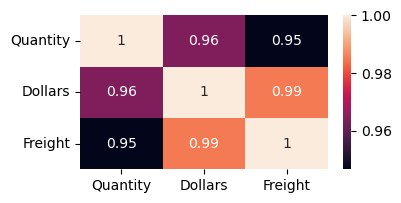

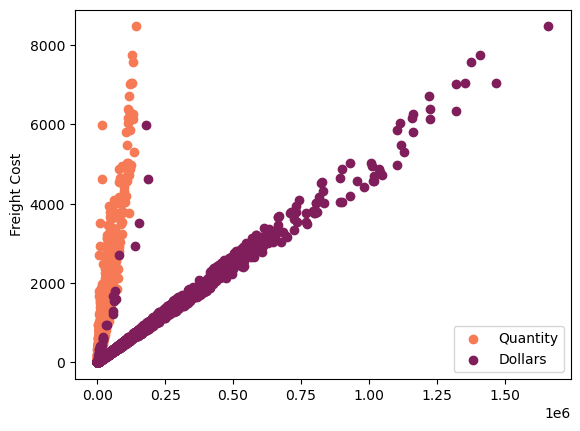

In [86]:
# Relationship between Quantity, Dollars and Freight
plt.figure(figsize=(4,2))
sns.heatmap(vendor_df[['Quantity', 'Dollars','Freight']].corr(),annot=True)
plt.show()

plt.scatter(vendor_df['Quantity'], vendor_df['Freight'], color= '#f57a55')
plt.scatter(vendor_df['Dollars'], vendor_df['Freight'], color= '#7f1e5a')
plt.legend(['Quantity', 'Dollars'])
plt.ylabel('Freight Cost')
plt.show()

In [87]:
vendor_df['freight_per_unit'] = vendor_df['Freight']/vendor_df['Quantity']

In [88]:
vendor_df.head()

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval,freight_per_unit
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None,0.578333
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None,0.571333
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None,0.922000
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None,0.290614
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None,0.221809


In [89]:

low_quantity = vendor_df['Quantity'].quantile(0.25)
high_quantity = vendor_df['Quantity'].quantile(0.75)


In [90]:
high_quantity, low_quantity

(np.float64(5100.5), np.float64(83.0))

In [91]:
vendor_df.loc[vendor_df['Quantity'] < low_quantity, 'freight_per_unit'].mean()

np.float64(0.09489854253138316)

In [92]:
vendor_df.loc[vendor_df['Quantity'] > high_quantity, 'freight_per_unit'].mean()

np.float64(0.049077654690759046)

In [93]:
X = vendor_df[['Quantity','Dollars']]
y = vendor_df['Freight']


In [94]:
vendor_df.describe()

,VendorNumber,PONumber,Quantity,Dollars,Freight,freight_per_unit
count,5543.00000,5543.000000,5543.000000,5.543000e+03,5543.000000,5543.000000
mean,20662.75212,10889.419087,6058.880931,5.807338e+04,295.954301,0.068242
std,34582.15841,1600.859969,14453.338164,1.402340e+05,713.585093,0.084333
min,2.00000,8106.000000,1.000000,4.140000e+00,0.020000,0.005367
25%,3089.00000,9503.500000,83.000000,9.678100e+02,5.020000,0.038561
50%,7240.00000,10890.000000,423.000000,4.765450e+03,24.730000,0.050824
75%,10754.00000,12275.500000,5100.500000,4.458718e+04,229.660000,0.074710
max,201359.00000,13661.000000,141660.000000,1.660436e+06,8468.220000,3.106000


In [95]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [96]:
X_train.shape, X_test.shape

((4434, 2), (1109, 2))

In [97]:
y_test.shape, y_train.shape

((1109,), (4434,))

In [98]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [99]:
model_1 =LinearRegression()
model_1.fit(X_train, y_train)

model_2 = DecisionTreeRegressor(max_depth= 4,random_state=42)
model_2.fit(X_train, y_train)

model_3 = RandomForestRegressor(max_depth = 5, random_state=42)
model_3.fit(X_train, y_train)


RandomForestRegressor(max_depth=5, random_state=42)

In [100]:
import numpy as np
def evaluate_model(model, X_test, y_test, Model_name):
    preds = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, preds)*100

    print(f"\n {Model_name} Peformence:")
    print(f"MAE : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R : {r2:.2f}%")    

In [101]:
evaluate_model(model_1, X_test, y_test, 'Linear Regression')

evaluate_model(model_2, X_test, y_test, 'Decision Tree Regressor')

evaluate_model(model_3, X_test, y_test, ' Random Forest Regressor')


 Linear Regression Peformence:
MAE : 24.46
RMSE : 124.43
R : 97.00%

 Decision Tree Regressor Peformence:
MAE : 38.12
RMSE : 138.25
R : 96.30%

  Random Forest Regressor Peformence:
MAE : 27.02
RMSE : 130.76
R : 96.69%


In [102]:
print(X_test.shape)
print(y_test.shape)

(1109, 2)
(1109,)


In [103]:
print("Intercept:", model_1.intercept_)

for feature, coefficient in zip(X_test.columns, model_1.coef_):
    print(f"{feature}: {coefficient:.4f}")

Intercept: 5.604873227096789
Quantity: -0.0020
Dollars: 0.0052


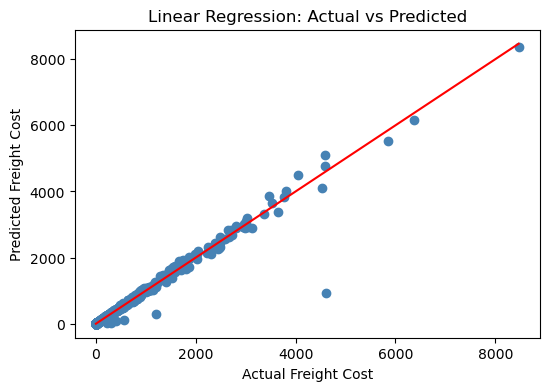

In [104]:
y_pred = model_1.predict(X_test)

plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, color="steelblue")

# Perfect prediction reference line
minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())
plt.plot([minimum, maximum], [minimum, maximum], color="red")

plt.xlabel("Actual Freight Cost")
plt.ylabel("Predicted Freight Cost")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

Required: ['Quantity' 'Dollars']
Available: ['InventoryId', 'Store', 'City', 'Brand', 'Description', 'Size', 'onHand', 'Price', 'endDate']


In [107]:
input_data = {
    "Quantity": [100, 50],   # replace with actual quantities
    "Dollars": [18500, 9000],
}

prediction_df = pd.DataFrame(input_data)

predictions = model_1.predict(prediction_df)
print(predictions)

[101.86809241  52.4329285 ]


In [108]:
print(prediction_df.columns.tolist())

['Quantity', 'Dollars']
